# Understanding Seattle Properties

### Introduction

We are working with data from the King County Assessor that has information on property, tax accounts, and residential buildings. Once combined, they include data about these buildings and properties, like lot size, zoning, zip code, square footage, number of bedrooms and bathrooms, and appraised value. 

We combined this with data from the American Community Survey that the U.S. Census Bureau conducts. This gave us data on demographic information such as race, median household income, owner versus renter, and median home value.
The question we are investigating is: “What underlying structure exists in Seattle property data, and how does it relate to land use patterns and geographic location?”

We built unsupervised learning models to better understand this data. The types of unsupervised learning we used included Principal Component Analysis (PCA), matrix completion, k-means clustering, and hierarchical clustering. We then examined our results looking for patterns in the data and how those patterns relate to zoning classification and geographic location.

### Theoretical Background

#### Principal Component Analysis, Singular Value Decomposition, and Matrix Completion
Principal Component Analysis (PCA) is a method of dimensionality reduction that helps to identify sets of correlated features within the data. In PCA, we rotate and scale our data set using some linear combinations of the original features to concentrate on the most interesting and varied directions. These combinations are otherwise referred to as 'principal components', and they represent the directions in which there is the greatest amount of variability within the data. 

The mathematical technique underlying PCA is known as singular value decomposition (SVD), a method that reduces a data set into smaller representations of the relationships between its data. This technique can help to understand the most important features within a given data set, as well as in generating new data to be imputed in place of missing data.

Matrix completion is a method of data imputation that fills in missing data by relying on the available data points. This is broadly accomplished over multiple iterations of singular value decomposition, where the principal components are used to capture the most important information within the data. The parameter ``M`` effectively represents the number of principal components that are used to generate new entries in place of the missing data, starting with the strongest principal component.

#### Clustering
We’ll be using unsupervised learning to group the data into different clusters. We can determine whether we have good cluster grouping in one of two ways. We can either look for the observations within a group to be as similar as possible, which would mean that we would want the observations to be tightly bunched within the groups. Alternatively, we can look for each group to be as dissimilar as possible, which would mean that we want the centers of the groups to be far apart from each other. 

One type of supervised learning is k-means clustering. In k-means clustering, we randomly assign each observation to an initial cluster assignment. Then we iterate by computing the centroid of each cluster then reassigning observations to the closest cluster centroid until the model has converged. Once the observations have all been assigned to the same cluster for a second iteration, the model has converged.
For k-means, we want to minimize the within-cluster variation:
 
K-means is sensitive to initialization. The way we deal with this is to run k-means many times in a row and choose the best version. 
We represent the number of clusters with the variable k. Determining which value of k is the best to use is more of an art than a science. One way to determine which value of k to use for k-means clustering is to plot the number of clusters against the within-cluster sum of squares. Then select a value of k in the elbow of the curve. 
Silhouette score is another way to choose k. Silhouette score is a computation of how well each observation fits in its own cluster. The equation for silhouette score, where ai is the mean distance between point i and others in the same cluster and bi is the mean distance between point i and others in the next closest cluster:
 
The silhouette score is between one and negative one. A positive silhouette score indicates that the clusters are cohesive and clearly separated. We want the silhouette score to be as close to one as possible. We want to plot silhouette score along with increasing k, and we also want to visualize the silhouette score on a biplot. Again, this is more of an art than a science. Sometimes the silhouette score will be slightly lower but the biplot will show that the clusters are better defined. 

Hierarchical clustering is like a combination of k-means clustering and a decision tree. Hierarchical clustering, also known as agglomerative clustering, builds clusters from the bottom up. At each iteration, the model groups observations where similarities are the highest or dissimilarities are the lowest. Once the model is build in this fashion, we can apply different values of k to the model. Thus, in hierarchical clustering we do not have to choose the value of k before creating the model.


### Methodology

#### Data Preprocessing 

The data set we utilized was compiled from multiple sources. First, three data sets were gathered from the King County Assessor, each respectively containing records for parcels, residential buildings, and real property tax accounts. These three sets were then collectively merged into a single data set.  

Following this, five data sets from the American Community Survey (ACS) were cleaned and merged. This data is collected by the US Census Bureau, and the five sets respectively contained respondent data on household income, tenure (whether a respondent rents or owns), race, home value, and rent burden. This collective set of ACS data was then merged with the Assessor data to form one large table of values for King County. This was further reduced to contain only parcels within the city of Seattle, resulting in roughly 163,000 observations total.

Multiple features (columns) of the data set were then removed in order to improve overall interpretability and eliminate redundancy. From the King County Assessor data, we retained key features of building data such as square footage, lot size, building grade, year built, year of the most recent renovation, number of bedrooms and bathrooms, number of living units, stories, garage square footage, overall building condition, and the appraised land value. From the ACS data, we maintained median household income, median home value, proportions of tenure status, proportion of racial groups, and a column of rent burden rate representing the share of renters spending 30% or more of their income on housing. In total, the merged dataset contained 58 columns/features overall. For some analyses, columns containing very similar data/patterns were dropped to avoid having two representations of the same information. Following this cleaning process, the data set contained 24 total features of numerical data. These columns also had their data standardized to possess a mean of zero such that no variables would possess inflated importance due to having data of a much greater scale.

#### Principal Component Analysis
Principal component analysis was applied to the reduced and scaled data set containing 24 features. Two scree plots of, respectively, single and cumulative variance with each additional principal component was then generated to convey how much each component contributes in terms of overall variance. The first two principal components were then compared to one another, along with the 24 features, in order to discern their overall importance. 

#### Matrix Completion
To demonstrate matrix completion on our data, we randomly omitted 1000 entries from our matrix and subsequently replaced them using singular value decomposition. A quick comparison was then performed between these estimated values and the true values that were originally omitted.

#### K-means Clustering
The k-means clustering was performed on the full data set. First k-means versus within-cluster sum of squares was plotted. Silhouette scores were calculated. The elbow method and silhouette scores were used to determine an appropriate value of k. Heat maps were created comparing the clusters to current zoning and to zip code.

#### Hierarchical Clustering
Null values were dropped so that hierarchical clustering would work. The data was sampled down to a size that would work with hierarchical clustering, 500 observations. The columns that identified the individual properties or that were not numeric were dropped. The data was scaled. A dendrogram showing the full hierarchical cluster was created. Another dendrogram showing only the top layers were created. Five clusters were used. Heat maps were created comparing the clusters to current zoning and to zip code.




### Results

#### PCA Results

The scree plot below shows the proportion of variance explained by each principal component individually, alongside the cumulative variance explained as more components are added. Around 15 components are needed to explain 90% of the cumulative variance in the data.

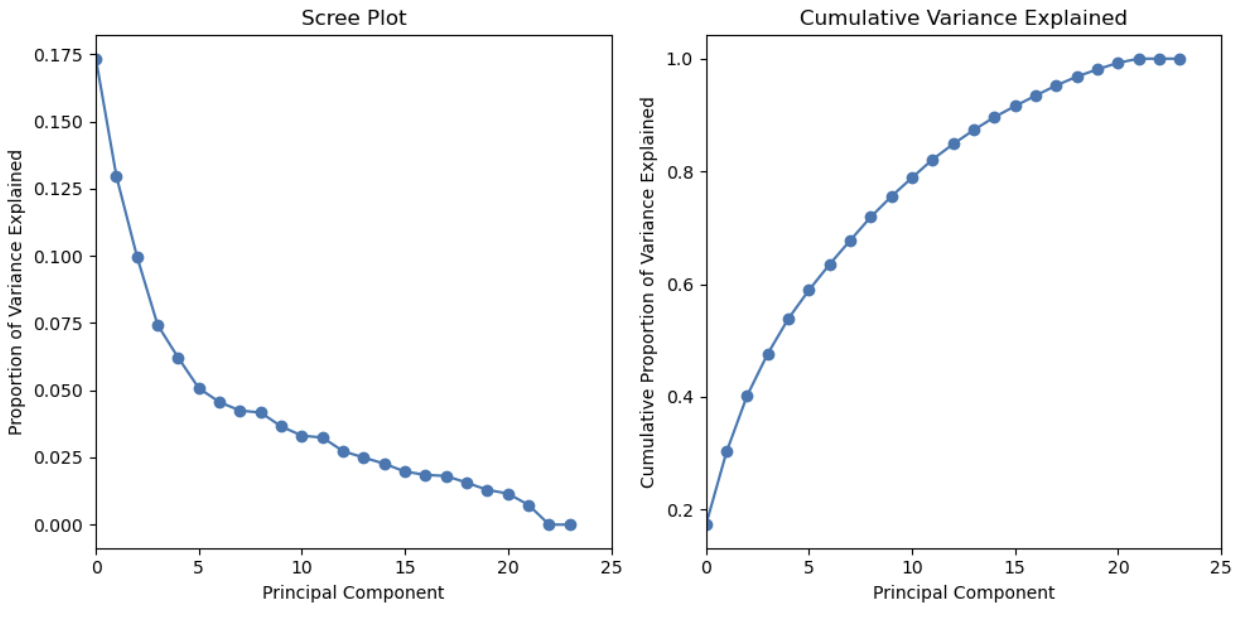


The comparison of the first two principal components below shows how much each feature contributes to either component. Each arrow's direction and magnitude respectively indicate how the observations relate to both component (positive or negative relationship) and how strongly they contribute to the variation in either component. 


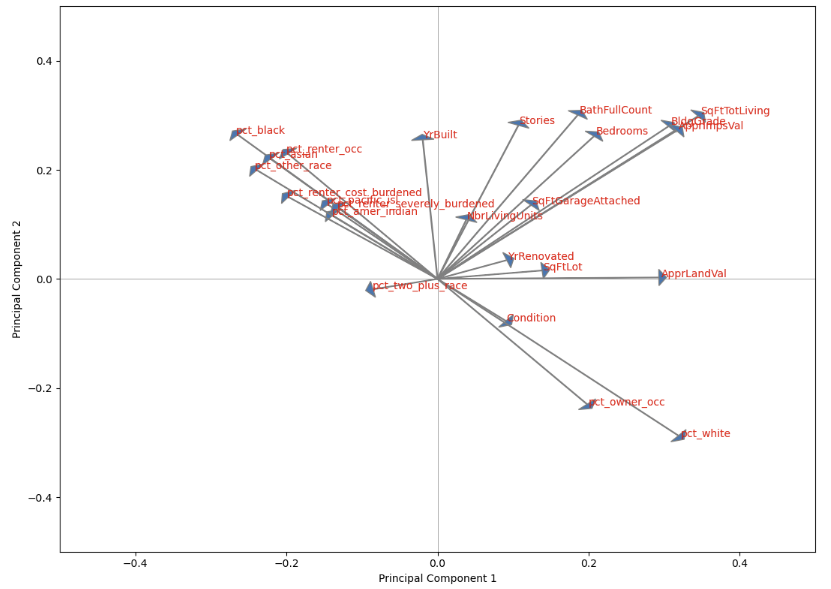

#### Matrix Completion 

Using an ``M`` value of 1, the matrix completion fell below the threshold set up within a single iteration. When comparing the new values computed to the original values that were omitted, they shared a correlation of around 0.30.

#### Clustering


Based on the dendrograms of the hierarchical clustering on a sample of the data, the data was separated into five clusters. 

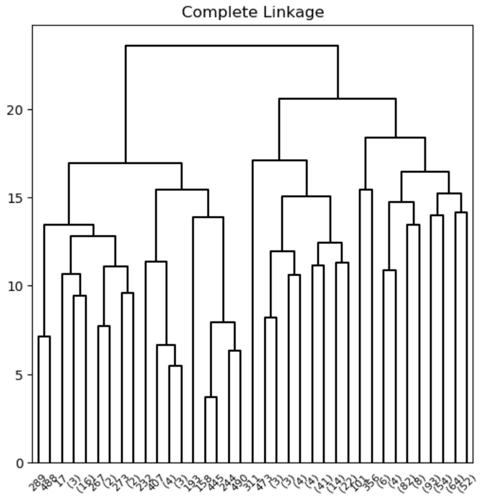

Below are heat maps of the clusters compared to the current zoning and clusters compared to the zip codes.

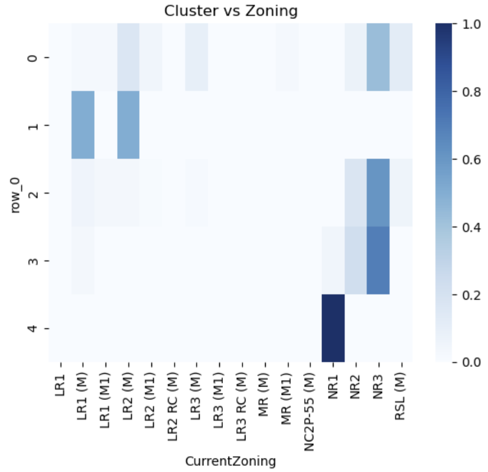

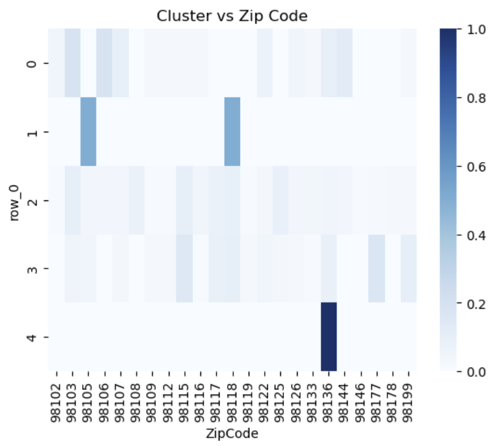

Below is the k-means versus within-cluster sum of squares plot.

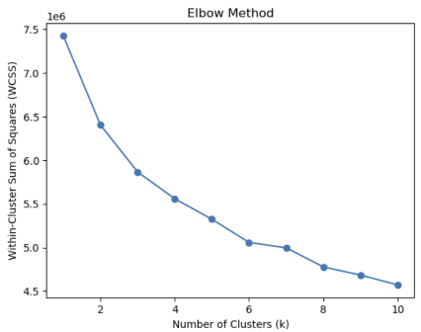

According to that plot, a k value of between three and five looked most promising. Silhouette scores were calculated, and a k value of three had the best score. 

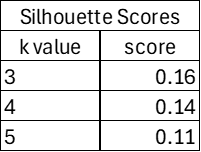

Therefore, three was chosen as the number of clusters. Heat maps were created comparing the clusters to current zoning and to zip code.

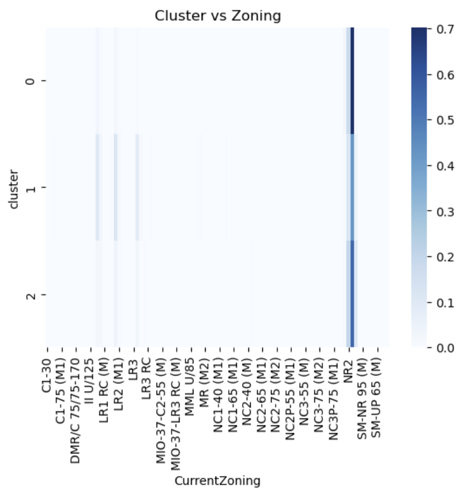

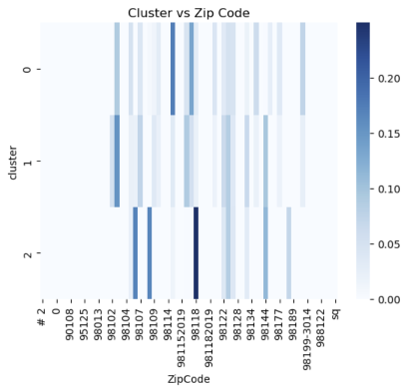


### Discussion

#### PCA and Matrix Completion

The shape of the curves in either scree plot reveals that no single component dominates the variation within the dataset. Instead, the variation appears well-distributed across the first 15 components to explain 90% of the total variance. This likely suggests that the data contains multiple important features that all contribute to the variance among the data points, with no single feature exhibiting outsized importance.

In the context of the underlying SVD of this analysis, the V* matrix from the SVD is equivalent to the rotation matrix that defines how each principal component relates to the overall features. Each row of this matrix would thus represent a principal component.

The plot of the two principal components differs from plotting on two original features because it accounts for all features within the data and how they contribute to the variance rather than simply comparing two features alone. When examining the first two principal components together, principal component 1 is shown as being strongly related to aspects of race as well as the value and tenure status of a given parcel, along with the square footage. The table below demonstrates that these features all have the strongest positive relationship with variance. The opposite effect was seen with the proportions of other racial groups, specifically Black and Asian, as well as those burdened by rent. With principal component 2, the factors that show the greatest variance are features of the building itself, such as the number of stories, number of bedrooms, and so on. These results suggest that home ownership, square footage, and race are the most impactful sources of variance across Seattle residences, followed independently by more specific features of the residences themselves.

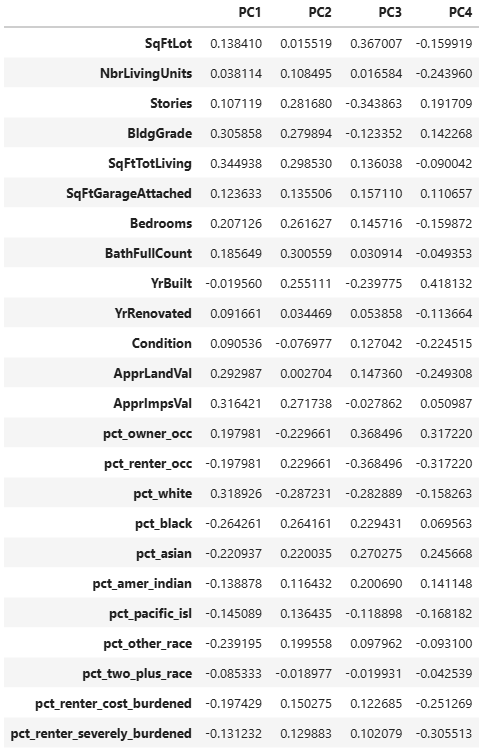

With matrix completion, the correlation value of 0.30 between the newly imputed data and the omitted data suggests that the first principal component does not sufficiently explain a majority of the variance in the data. This backs up what was observed in the PCA results, where many principal components (~15) were required to reach 90% of the total variance explained. Additional values of ``M`` may have to be experimented with to see if more accurate data can be generated to fill the missing data.


#### Clustering
In the hierarchical clustering, cluster one shows more association with mixed uses zone, while the other clusters show more association with neighborhood residential zones. Cluster four shows high association with lower density neighborhood residential zones. There does appear to be some correlation between zoning types and clusters.

The heatmap from the hierarchical clustering shows cluster distribution across zip codes. There is light shading across many zip codes for most of the clusters.  This suggests that the clustering is not highly associated with geographic location. However, cluster four has dark shading in one zip code. This cluster does seem to be associated with one location, which may have distinct characteristics.

For the k-means clustering compared to zoning, Cluster 0 is dominated by NR2 zoning, which is neighborhood residential zoning. The other clusters also show a lot of NR2 zoning. It is a factor in all the clusters, but it doesn't uniquely define one cluster since it is present in all of them.

The k-means clusters align more closely with zoning than with zip codes. This suggests that the variables we are using as predictors are more closely related to land use regulation than geographic boundaries. Some clusters show concentration in some zip codes. The clustering is not primarily driven by geographic location.


### Conclusion

The unsupervised analyses we performed aimed to discern patterns in Seattle's housing using multiple techniques.  From principal component analysis and matrix completion, a consistent finding was that the dominant features of variation included square footage, race, tenure status, and housing cost burden. With clustering, it was observed that most of the clusters did not adhere to strict geographic boundaries, barring one. This result likely suggests that other factors regarding the parcels, such as those identified in PCA, are the more impactful factors in terms of variance.

These results can directly contribute to future housing policy within the city of Seattle. By identifying the factors that most impact the extreme differences across Seattle's residences, one could further this analysis via predictive modeling to identify which communities are the most vulnerable and may require additional assistance in the form of rent control, housing assistance, or overall housing reform. As the clustering analysis showed, the patterns of great disparity are not confined to specific geographic zones, indicating that more intensive work is required to identify those in need. The patterns seen within this analysis could also be further expanded to compare with historical boundaries in Seattle due to redlining. This would allow for an exploration of how much our present-day housing data may reflect this not so distant past.